
# Real Data Gap Evaluation

実データからの最尤推定と外付けHDD上のデータを利用し、深層学習モデルと推移率行列ベース推定の寿命ギャップを比較します。


In [1]:

import sys
import os
from pathlib import Path

sys.path.append(os.path.abspath("../"))

import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

from utils.likelihood import Likelihood_diagonal_exp
from utils.formate_matrix_toMLData import matrix_trimer, formate_dataMatrix
from models.model_0929 import DeepSets_varSets_forDiagnel, collate_fn, varSets_Datasets

import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

plt.rcParams["font.size"] = 18
np.set_printoptions(suppress=True, precision=4)


In [2]:

DATA_NAME = "shoban"
CSV_PATH = f"../real_data/{DATA_NAME}.csv"
MODEL_PATH = "../model_weights/mixed_distribution/mixed_0929.pth"

TIME_SCALE = 1.0
MLE_INITIAL_GUESS = np.array([-0.5, -1.0, -1.5])
OUTLIER_PERCENTILE = 90 # remove top 5% largest LL gaps
EPS = 1e-9

EXTERNAL_DATASETS = {
    "n200": {"path": "/media/user/TRANSCEND/datas/real_data/shoban/samples_200", "ll_use": False},
    "n400": {"path": "/media/user/TRANSCEND/datas/real_data/shoban/samples_400", "ll_use": False},
    "n600": {"path": "/media/user/TRANSCEND/datas/real_data/shoban/samples_600", "ll_use": False},
    "n800": {"path": "/media/user/TRANSCEND/datas/real_data/shoban/samples_800", "ll_use": False},
    "n1000": {"path": "/media/user/TRANSCEND/datas/real_data/shoban/samples_1000", "ll_use": False},
}

VALID_EXTENSIONS = (".csv", ".txt")
IGNORED_PREFIXES = ("._", ".DS_Store", "Thumbs.db")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FORMATER = formate_dataMatrix()

print(f"Using device: {DEVICE}")
print(f"Target CSV: {Path(CSV_PATH).resolve()}")


Using device: cuda
Target CSV: /home/user/Documents/python/CTMCxDeepSets/real_data/shoban.csv



## 1. 実データの読み込みと前処理


In [3]:

def preprocess_real_dataframe(df: pd.DataFrame, data_name: str) -> pd.DataFrame:
    df = df.copy()
    if data_name == "suidou":
        df = df.rename(columns={'建設時健全度（1と仮定）': "pre", '調査時健全度': "post", '経過年数': "time"})
    elif data_name == "shoban":
        df = df.rename(columns={'Be(1-4)': "pre", 'Af(1-4)': "post", 'Ins': "time"})
    elif data_name == "Frank":
        def grading(x):
            if x <= 30:
                return 1
            elif x <= 50:
                return 2
            elif x <= 70:
                return 3
            else:
                return 4
        df["Post_IRI_Class"] = df['Post-State IRI'].apply(grading)
        df["Pre_IRI_Class"] = df['Pre-State IRI'].apply(grading)
        df["time"] = df['Inspection Time of PostState IRI'] - df['Inspection Time of Prestate']
        df = df.rename(columns={'Pre_IRI_Class': "pre", 'Post_IRI_Class': "post"})
    elif data_name == "Tunnel":
        df = df.rename(columns={'事前健全度': "pre", '事後健全度': "post", '検査間隔(年)': "time"})
        df = df[["pre", "post", "time"]]
        df = df.dropna()
        df["pre"] = df["pre"].astype(int)
        df["post"] = df["post"].astype(int)
    elif data_name == "RCBridge":
        df = df.rename(columns={0: "pre", 1: "post", 2: "time"})
        df = df[(df["pre"] < 4) & (df["post"] < 5)]

    required = {"pre", "post", "time"}
    if not required.issubset(df.columns):
        missing = required - set(df.columns)
        raise KeyError(f"Missing columns for preprocessing: {missing}")

    cleaned = df[["pre", "post", "time"]].dropna().copy()
    cleaned["pre"] = cleaned["pre"].astype(int)
    cleaned["post"] = cleaned["post"].astype(int)
    cleaned["time"] = cleaned["time"].astype(float)
    cleaned = cleaned[cleaned["time"] > 0]
    return cleaned.reset_index(drop=True)

def load_real_dataset(csv_path: str, data_name: str) -> pd.DataFrame:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"{csv_path} not found.")
    if data_name == "RCBridge":
        df = pd.read_csv(csv_path, header=None)
    else:
        df = pd.read_csv(csv_path)
    return preprocess_real_dataframe(df, data_name)


Loaded 13803 inspection pairs for shoban.


,pre,post,time
0,1,1,22.0
1,1,1,2.0
2,1,1,1.0
3,1,1,1.0
4,1,1,3.0


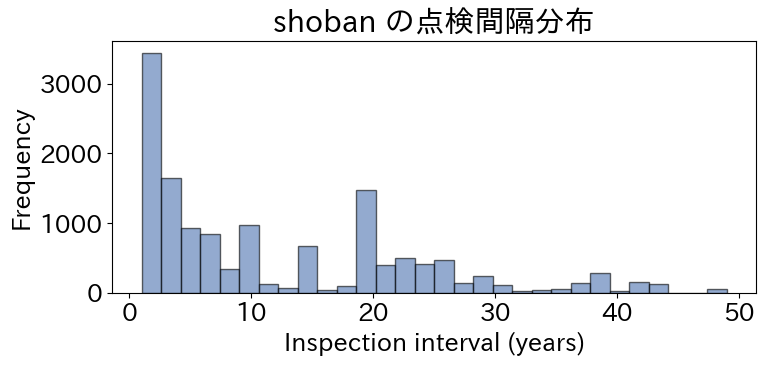

In [4]:

real_df = load_real_dataset(CSV_PATH, DATA_NAME)
print(f"Loaded {len(real_df)} inspection pairs for {DATA_NAME}.")
display(real_df.head())

plt.figure(figsize=(8, 4))
plt.hist(real_df["time"], bins=30, alpha=0.6, color="#4C72B0", edgecolor="black")
plt.xlabel("Inspection interval (years)")
plt.ylabel("Frequency")
plt.title(f"{DATA_NAME} の点検間隔分布")
plt.tight_layout()
plt.show()



## 2. 実データを用いた最尤推定


In [5]:

states = real_df[["pre", "post"]].to_numpy(dtype=float)
delta_t = (real_df["time"] / TIME_SCALE).to_numpy(dtype=float)

likelihood_input = np.column_stack((states, delta_t))
likelihood = Likelihood_diagonal_exp(likelihood_input)
estimated_Q = likelihood.optimize(MLE_INITIAL_GUESS)
diag_vec = FORMATER.GetOutputVector_byDiagonal(estimated_Q)
estimated_lifespan_years = (1.0 / (diag_vec + EPS)) * TIME_SCALE

REFERENCE_LIFESPAN_VEC = estimated_lifespan_years.copy()
reference_lifespan = pd.Series(
    estimated_lifespan_years,
    index=["State1→2", "State2→3", "State3→4"],
    name="Estimated lifespan (years)",
)

print("推定された期待寿命 (年):")
display(reference_lifespan.to_frame())


推定された期待寿命 (年):


,Estimated lifespan (years)
State1→2,45.628427
State2→3,7.333449
State3→4,9.848902



## 3. モデル読み込み


In [6]:

model = DeepSets_varSets_forDiagnel(device=DEVICE).to(DEVICE)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
print("DeepSets model loaded.")


DeepSets model loaded.


/tmp/ipykernel_188271/3091310695.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=DEVICE)



## 4. 外付けHDD上のデータ + 推論ヘルパー


In [7]:

def safe_inverse(values, eps: float = EPS):
    values = np.asarray(values, dtype=float)
    return 1.0 / (values + eps)

def parse_external_file(file_path: Path, ll_use: bool = True):
    with open(file_path, "rb") as f:
        matrix = np.loadtxt(f, delimiter=",")
    trimer = matrix_trimer(matrix)
    if ll_use:
        ll_trm = trimer.trim_transitionRateMatrix(start=4, end=8)
        ll_vec = FORMATER.GetOutputVector_byDiagonal(ll_trm)
        data = trimer.trim_data(start=8)
    else:
        data = trimer.trim_data(start=4)
        ll_trm=trimer.trim_transitionRateMatrix(start=0, end=4)
        ll_vec=ll_vec = FORMATER.GetOutputVector_byDiagonal(ll_trm)
        
    if data.size == 0:
        raise ValueError("No inspection rows found.")
    state_seq = np.stack([data[:, 0], data[:, 1]], axis=0)
    delta_t = data[:, 2]
    return state_seq, delta_t, ll_vec

def load_external_dataset(label: str, cfg: dict):
    directory = Path(cfg["path"])
    ll_use = cfg.get("ll_use", True)
    if not directory.exists():
        print(f"⚠️ {label}: {directory} not found. Skipping.")
        return None
    states, deltas, targets = [], [], []
    for file_path in sorted(directory.iterdir()):
        if file_path.is_dir():
            continue
        if file_path.name.startswith(IGNORED_PREFIXES):
            continue
        if file_path.suffix.lower() not in VALID_EXTENSIONS:
            continue
        try:
            state_seq, delta_t, ll_vec = parse_external_file(file_path, ll_use=ll_use)
        except Exception as exc:
            print(f"  Skipped {file_path.name}: {exc}")
            continue
        states.append(state_seq)
        deltas.append(delta_t)
        targets.append(ll_vec)
    if not states:
        print(f"⚠️ {label}: no valid samples in {directory}.")
        return None
    print(f"Loaded {len(states)} sequences for {label} from {directory}.")
    return states, deltas, targets

def run_model_inference(states, deltas, targets):
    dataset = varSets_Datasets(states, deltas, targets)
    dataloader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=collate_fn,
        pin_memory=torch.cuda.is_available(),
    )
    pred_expectations = []
    ll_expectations = []
    with torch.no_grad():
        for state_batch, delta_batch, target_batch, lengths in dataloader:
            state_batch = state_batch.to(DEVICE)
            delta_batch = delta_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            lengths = lengths.to(DEVICE)

            outputs = model(state_batch, delta_batch, lengths)
            pred_expectations.extend(safe_inverse(outputs.cpu().numpy()))
            ll_expectations.extend(safe_inverse(target_batch.cpu().numpy()))
    return np.array(pred_expectations), np.array(ll_expectations)



## 5. データセットごとの推論


In [8]:

dataset_results = {}

for label, cfg in EXTERNAL_DATASETS.items():
    loaded = load_external_dataset(label, cfg)
    if loaded is None:
        continue
    states, deltas, targets = loaded
    pred_expect, ll_expect = run_model_inference(states, deltas, targets)
    dataset_results[label] = {
        "pred_expect": pred_expect,
        "ll_expect": ll_expect,
    }

if not dataset_results:
    print("No datasets loaded. Please check EXTERNAL_DATASETS paths.")
else:
    for label, res in dataset_results.items():
        print(f"{label}: {res['pred_expect'].shape[0]} samples")


Loaded 200 sequences for n200 from /media/user/TRANSCEND/datas/real_data/shoban/samples_200.
Loaded 200 sequences for n400 from /media/user/TRANSCEND/datas/real_data/shoban/samples_400.
Loaded 200 sequences for n600 from /media/user/TRANSCEND/datas/real_data/shoban/samples_600.
Loaded 200 sequences for n800 from /media/user/TRANSCEND/datas/real_data/shoban/samples_800.
Loaded 200 sequences for n1000 from /media/user/TRANSCEND/datas/real_data/shoban/samples_1000.
n200: 200 samples
n400: 200 samples
n600: 200 samples
n800: 200 samples
n1000: 200 samples



## 6. ギャップ計測と可視化


In [9]:

trim_report = []
clean_gap_ll_dict = {}
clean_gap_eval_dict = {}
mask_registry = {}
reference_vec = REFERENCE_LIFESPAN_VEC.reshape(1, -1)
ordered_labels = []
for key in EXTERNAL_DATASETS.keys():
    if key in dataset_results:
        ordered_labels.append(key)
for key in dataset_results.keys():
    if key not in ordered_labels:
        ordered_labels.append(key)

trim_fraction = max(0.0, min(1.0, (100 - OUTLIER_PERCENTILE) / 100.0))

for label in ordered_labels:
    res = dataset_results[label]
    ll_expect = np.asarray(res["ll_expect"], dtype=float)
    eval_expect = np.asarray(res["pred_expect"], dtype=float)

    if ll_expect.size == 0:
        print(f"{label}: no samples -> skipped.")
        continue

    ll_gap = np.abs(ll_expect - reference_vec)
    eval_gap = np.abs(eval_expect - reference_vec)
    norms = np.linalg.norm(ll_gap, axis=1)

    if norms.size == 0:
        print(f"{label}: empty norms -> skipped.")
        continue

    threshold = np.percentile(norms, OUTLIER_PERCENTILE)
    mask = norms <= threshold
    removed = int(norms.size - mask.sum())

    if removed == 0 and trim_fraction > 0:
        remove_count = max(1, int(np.ceil(norms.size * trim_fraction)))
        keep_count = max(0, norms.size - remove_count)
        if keep_count == 0:
            mask = np.ones_like(norms, dtype=bool)
        else:
            keep_idx = np.argsort(norms)[:keep_count]
            mask = np.zeros_like(norms, dtype=bool)
            mask[keep_idx] = True
        removed = int(norms.size - mask.sum())

    clean_gap_ll_dict[label] = ll_gap[mask]
    clean_gap_eval_dict[label] = eval_gap[mask]
    mask_registry[label] = mask

    trim_report.append((label, int(norms.size), int(mask.sum()), removed))
    print(f"{label}: kept {int(mask.sum())} / {int(norms.size)} samples (removed {removed}).")

print()
print("Trim summary:")
for label, total, kept, removed in trim_report:
    ratio = kept / total if total else 0
    print(f"  {label}: kept {kept} ({ratio:.1%}), removed {removed}")


n200: kept 180 / 200 samples (removed 20).
n400: kept 180 / 200 samples (removed 20).
n600: kept 180 / 200 samples (removed 20).
n800: kept 180 / 200 samples (removed 20).
n1000: kept 180 / 200 samples (removed 20).

Trim summary:
  n200: kept 180 (90.0%), removed 20
  n400: kept 180 (90.0%), removed 20
  n600: kept 180 (90.0%), removed 20
  n800: kept 180 (90.0%), removed 20
  n1000: kept 180 (90.0%), removed 20


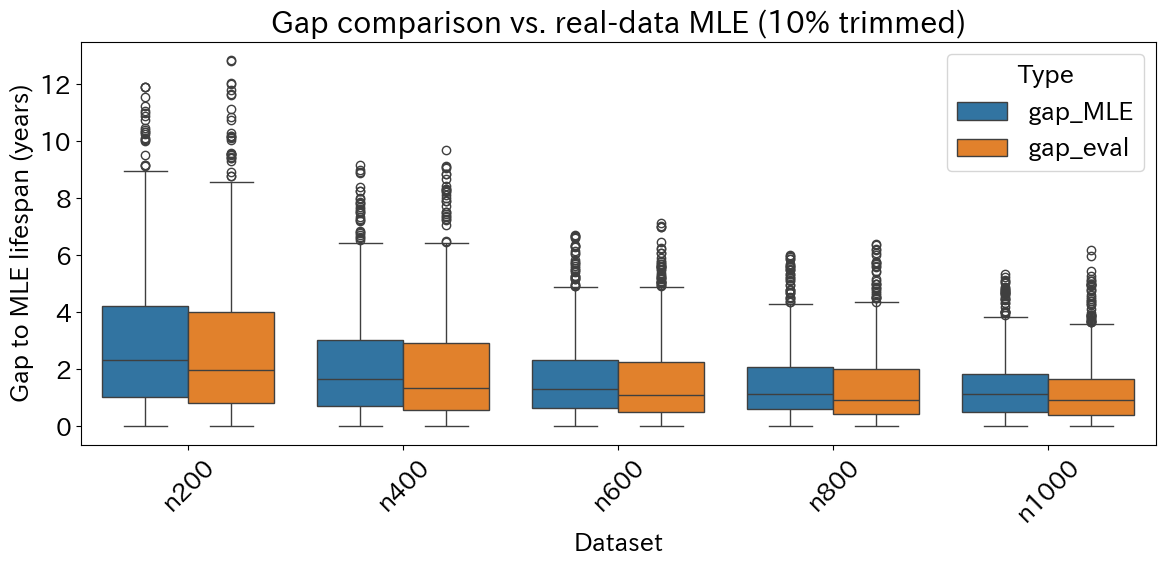

In [10]:

plot_rows = []
for label in ordered_labels:
    ll_vals = clean_gap_ll_dict.get(label)
    eval_vals = clean_gap_eval_dict.get(label)
    if ll_vals is None or eval_vals is None:
        continue
    for value in ll_vals.ravel():
        plot_rows.append({"Dataset": label, "Type": "gap_MLE", "Value": value})
    for value in eval_vals.ravel():
        plot_rows.append({"Dataset": label, "Type": "gap_eval", "Value": value})

if plot_rows:
    gap_df = pd.DataFrame(plot_rows)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=gap_df, x="Dataset", y="Value", hue="Type")
    plt.ylabel("Gap to MLE lifespan (years)")
    plt.title(f"Gap comparison vs. real-data MLE ({100 - OUTLIER_PERCENTILE}% trimmed)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No gap data available for visualization.")


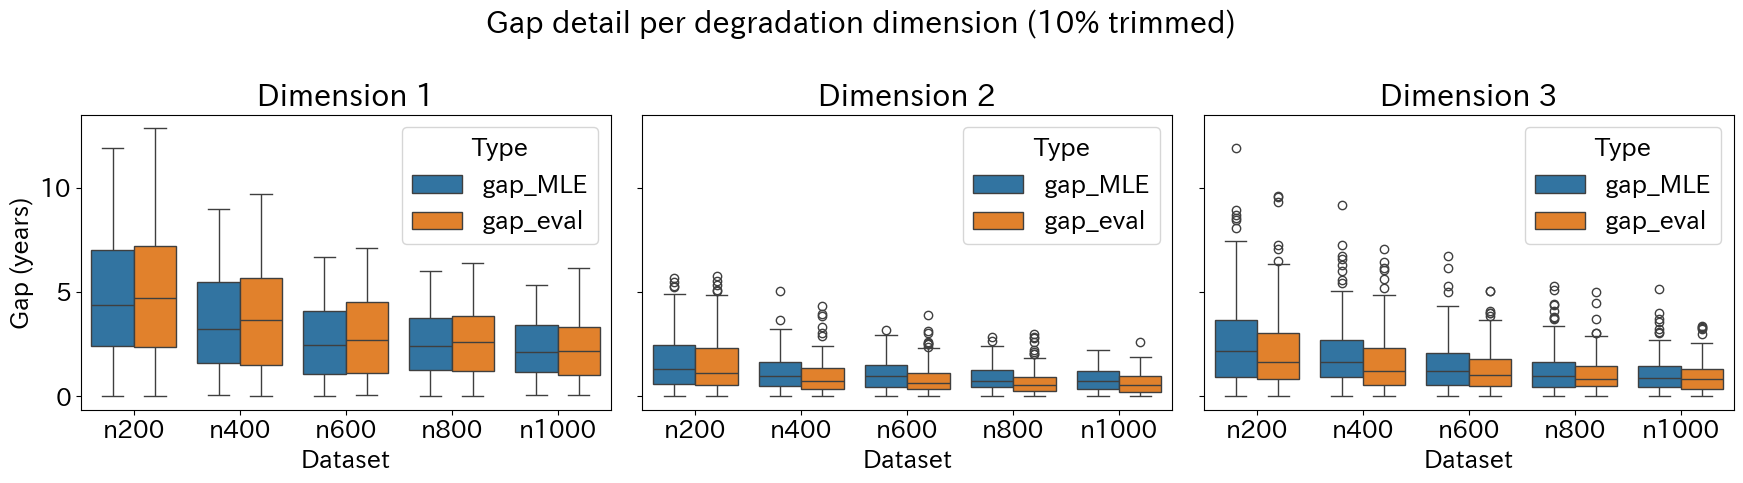

In [11]:

dim_rows = []
for label in ordered_labels:
    ll_vals = clean_gap_ll_dict.get(label)
    eval_vals = clean_gap_eval_dict.get(label)
    if ll_vals is None or eval_vals is None:
        continue
    for vec in ll_vals:
        for dim_idx, value in enumerate(vec):
            dim_rows.append({"Dataset": label, "Type": "gap_MLE", "Dim": dim_idx, "Value": value})
    for vec in eval_vals:
        for dim_idx, value in enumerate(vec):
            dim_rows.append({"Dataset": label, "Type": "gap_eval", "Dim": dim_idx, "Value": value})

if dim_rows:
    dim_df = pd.DataFrame(dim_rows)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for dim_idx in range(3):
        ax_df = dim_df[dim_df["Dim"] == dim_idx]
        if ax_df.empty:
            axes[dim_idx].axis("off")
            axes[dim_idx].set_title(f"Dimension {dim_idx + 1}")
            continue
        sns.boxplot(data=ax_df, x="Dataset", y="Value", hue="Type", ax=axes[dim_idx])
        axes[dim_idx].set_title(f"Dimension {dim_idx + 1}")
        axes[dim_idx].set_xlabel("Dataset")
        axes[dim_idx].set_ylabel("Gap (years)")
    plt.suptitle(f"Gap detail per degradation dimension ({100 - OUTLIER_PERCENTILE}% trimmed)")
    plt.tight_layout()
    plt.show()
else:
    print("No per-dimension gap data to plot.")


In [12]:

summary_rows = []
for label in ordered_labels:
    ll_vals = clean_gap_ll_dict.get(label)
    eval_vals = clean_gap_eval_dict.get(label)
    mask = mask_registry.get(label)
    if ll_vals is None or eval_vals is None:
        continue
    kept = int(ll_vals.shape[0])
    removed = int(mask.size - mask.sum()) if mask is not None else 0
    total = kept + removed
    summary_rows.append({
        "Dataset": label,
        "kept_samples": kept,
        "removed_samples": removed,
        "kept_ratio": kept / total if total else np.nan,
        "gap_eval_mean": float(np.mean(eval_vals)),
        "gap_eval_median": float(np.median(eval_vals)),
        "gap_MLE_mean": float(np.mean(ll_vals)),
        "gap_MLE_median": float(np.median(ll_vals)),
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)
else:
    print("Summary is empty. Check dataset loading results.")


,Dataset,kept_samples,removed_samples,kept_ratio,gap_eval_mean,gap_eval_median,gap_MLE_mean,gap_MLE_median
0,n200,180,20,0.9,2.872910,1.985584,3.054211,2.330164
1,n400,180,20,0.9,2.121076,1.327397,2.227384,1.654597
2,n600,180,20,0.9,1.646939,1.104166,1.731386,1.316327
3,n800,180,20,0.9,1.447143,0.924646,1.568319,1.141509
4,n1000,180,20,0.9,1.291146,0.920259,1.396599,1.116310
